In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv(r"../../data/cities_air_quality_water_pollution.18-10-2021 (1).csv")


,City,"""Region""","""Country""","""AirQuality""","""WaterPollution"""
0,New York City,"""New York""","""United States of America""",46.816038,49.504950
1,"Washington, D.C.","""District of Columbia""","""United States of America""",66.129032,49.107143
2,San Francisco,"""California""","""United States of America""",60.514019,43.000000
3,Berlin,"""""","""Germany""",62.364130,28.612717
4,Los Angeles,"""California""","""United States of America""",36.621622,61.299435


['City', ' "Region"', ' "Country"', ' "AirQuality"', ' "WaterPollution"']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3963 entries, 0 to 3962
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               3963 non-null   object 
 1    "Region"          3963 non-null   object 
 2    "Country"         3963 non-null   object 
 3    "AirQuality"      3963 non-null   float64
 4    "WaterPollution"  3963 non-null   float64
dtypes: float64(2), object(3)
memory usage: 154.9+ KB


(3963, 5)

,count,mean,std,min,25%,50%,75%,max
"""AirQuality""",3963.0,62.253452,30.944753,0.0,37.686567,69.444444,87.500000,100.0
"""WaterPollution""",3963.0,44.635372,25.663910,0.0,25.000000,50.000000,57.719393,100.0


### Data Cleaning

In [13]:
df=df.map(lambda x: x.replace('"','')if isinstance(x,str)else x)


City               0
 Region            0
 Country           0
 AirQuality        0
 WaterPollution    0
dtype: int64

False

### Data Visualization

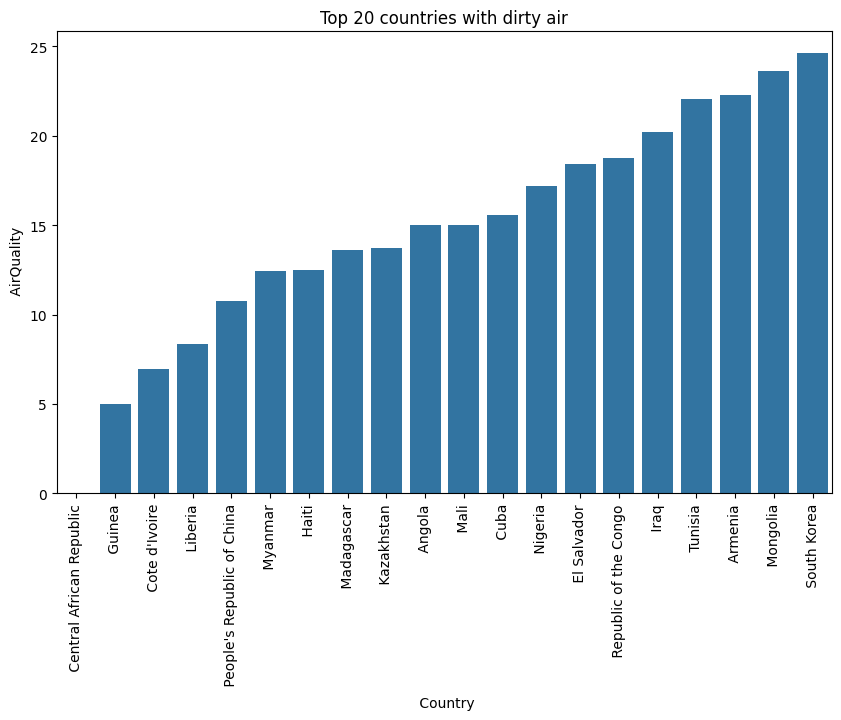

In [26]:
bottom_20_air=df.groupby(' Country')[' AirQuality'].mean().sort_values(ascending=True).head(20)


plt.figure(figsize=(10,6))
sns.barplot(x=bottom_20_air.index,y=bottom_20_air)
plt.xticks(rotation=90)
plt.title('Top 20 countries with dirty air')


In [24]:
bottom_20_air = df.groupby(' Country')[' AirQuality'].mean().sort_values(ascending=True).head(20)


 Country
 Central African Republic       0.000000
 Guinea                         5.000000
 Cote d'Ivoire                  6.944444
 Liberia                        8.333333
 People's Republic of China    10.761067
 Myanmar                       12.462207
 Haiti                         12.500000
 Madagascar                    13.636364
 Kazakhstan                    13.737825
 Angola                        15.000000
 Mali                          15.000000
 Cuba                          15.555556
 Nigeria                       17.162162
 El Salvador                   18.421053
 Republic of the Congo         18.750000
 Iraq                          20.189394
 Tunisia                       22.037037
 Armenia                       22.270115
 Mongolia                      23.590686
 South Korea                   24.597575
Name:  AirQuality, dtype: float64

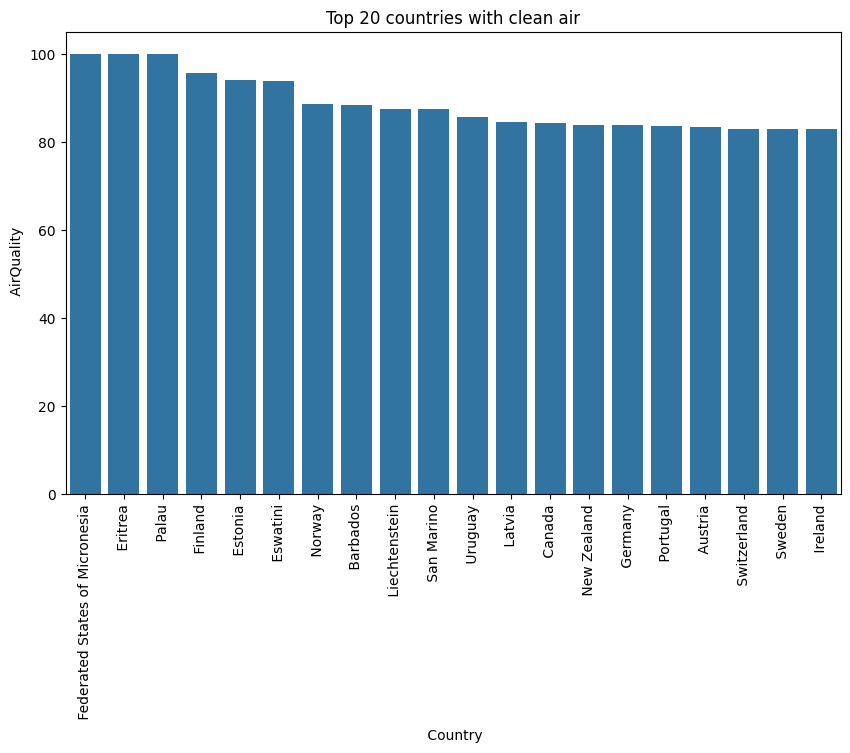

In [29]:
top_20_air=df.groupby(' Country')[' AirQuality'].mean().sort_values(ascending=False).head(20)


plt.figure(figsize=(10,6))
sns.barplot(x=top_20_air.index,y=top_20_air)
plt.xticks(rotation=90)
plt.title('Top 20 countries with clean air')


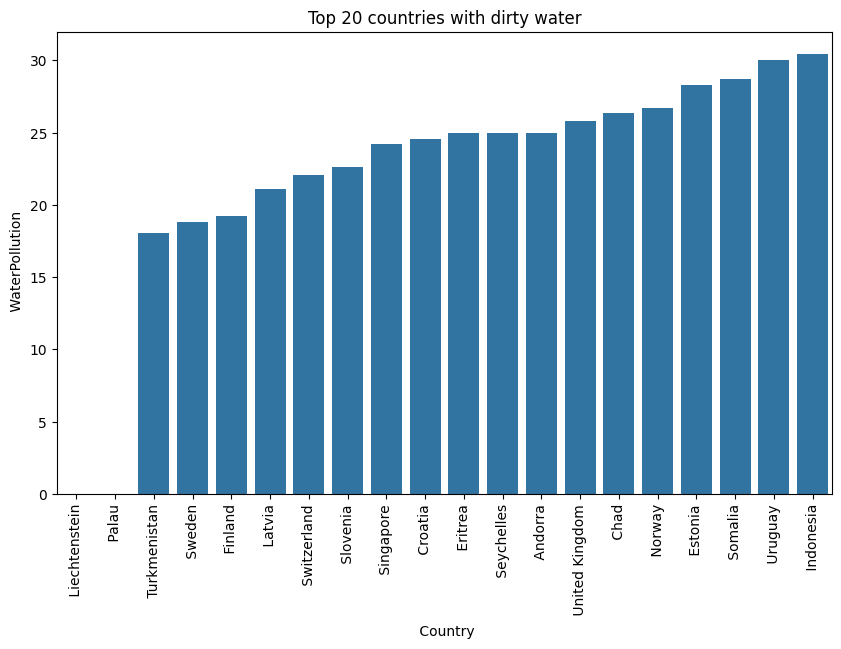

In [31]:
bottom_20_water=df.groupby(' Country')[' WaterPollution'].mean().sort_values(ascending=True).head(20)


plt.figure(figsize=(10,6))
sns.barplot(x=bottom_20_water.index,y=bottom_20_water)
plt.xticks(rotation=90)
plt.title('Top 20 countries with dirty water')


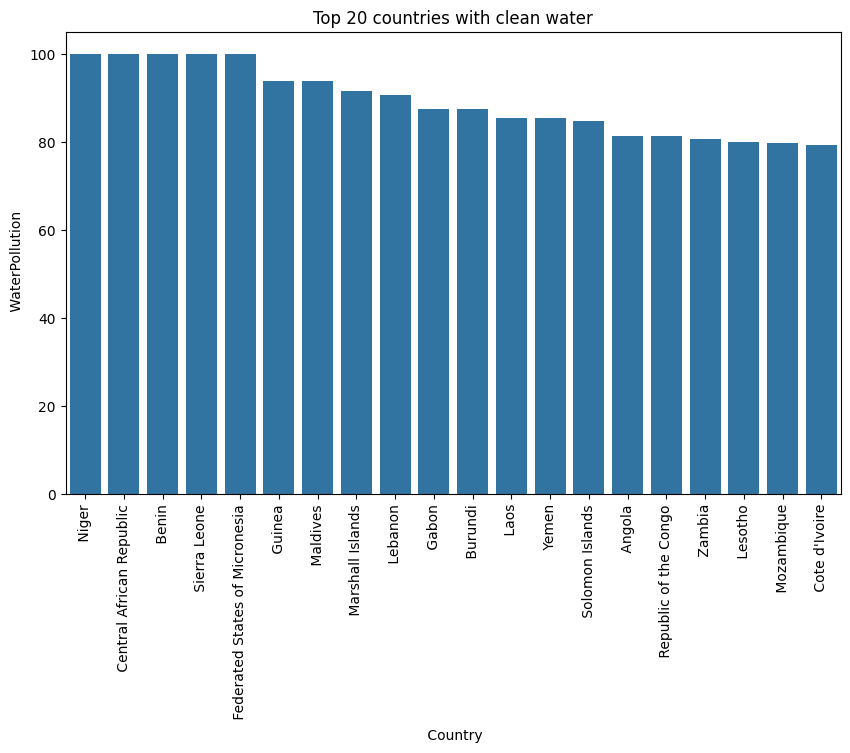

In [32]:
top_20_water=df.groupby(' Country')[' WaterPollution'].mean().sort_values(ascending=False).head(20)


plt.figure(figsize=(10,6))
sns.barplot(x=top_20_water.index,y=top_20_water)
plt.xticks(rotation=90)
plt.title('Top 20 countries with clean water')


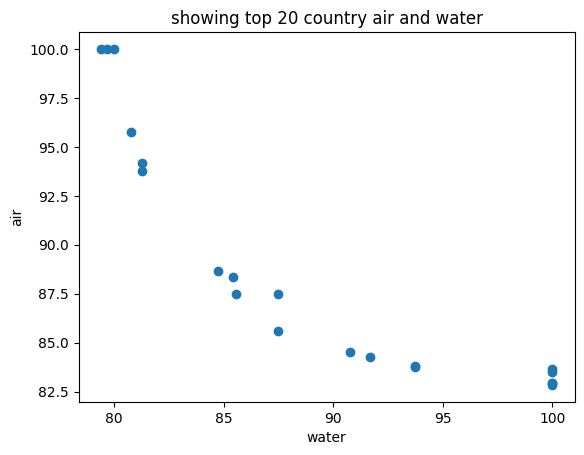

In [37]:
plt.scatter(top_20_water,top_20_air)
plt.xlabel('water')
plt.ylabel('air')
plt.title("showing top 20 country air and water")


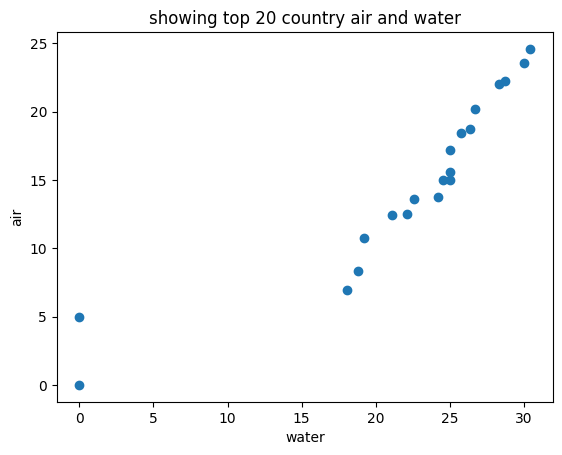

In [36]:
plt.scatter(bottom_20_water,bottom_20_air)
plt.xlabel('water')
plt.ylabel('air')
plt.title("showing top 20 country air and water")


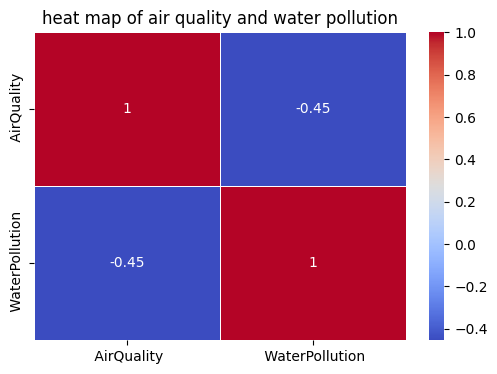

In [41]:
water_air=[' AirQuality',' WaterPollution']
df1=df[water_air].corr()
plt.figure(figsize=(6,4))
sns.heatmap(df1,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('heat map of air quality and water pollution')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


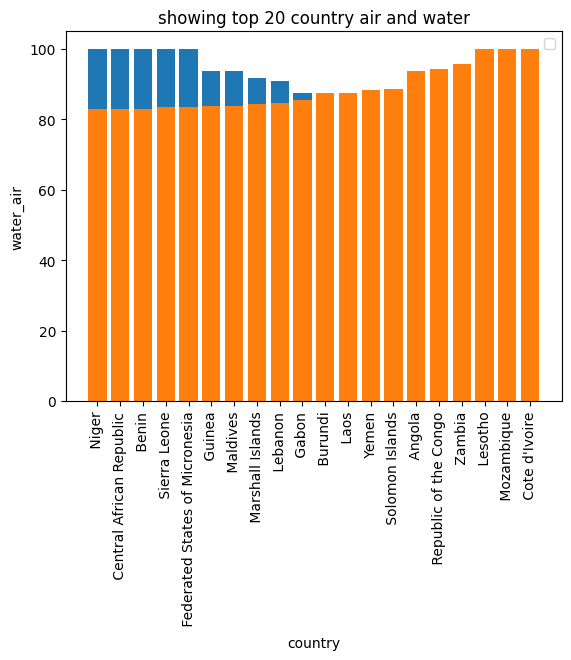

In [44]:
plt.bar(top_20_water.index,top_20_water)
plt.bar(top_20_water.index,top_20_air)
plt.xticks(rotation=90)
plt.xlabel('country')
plt.ylabel('water_air')
plt.legend()
plt.title("showing top 20 country air and water")
